**Daily Challenge : Building an agent with LangGraph and the Gemini API**

In [1]:
%pip install -qU langgraph langchain-google-genai google-genai

In [2]:
import os
from google.colab import userdata

GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")

if GOOGLE_API_KEY is None:
    raise ValueError("GOOGLE_API_KEY secret not found")

os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [4]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class OrderState(TypedDict):
    """State representing the customer's order conversation."""

    # The chat conversation. This preserves the conversation history
    # between nodes. The `add_messages` annotation indicates to LangGraph
    # that state is updated by appending returned messages, not replacing
    # them.
    messages: Annotated[list, add_messages]

    # The customer's in-progress order.
    order: list[str]

    # Flag indicating that the order is placed and completed.
    finished: bool
# The system instruction defines how the chatbot is expected to behave and includes
# rules for when to call different functions, as well as rules for the conversation, such
# as tone and what is permitted for discussion.
BARISTABOT_SYSINT = (
    "system",  # 'system' indicates the message is a system instruction.
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!",
)

# This is the message with which the system opens the conversation.
WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

In [5]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

# Try using different models. The `pro` models perform the best, especially
# with tool-calling. The `flash` models are super fast, and are a good choice
# if you need to use the higher free-tier quota.
# Check out the features and quota differences here: https://ai.google.dev/pricing
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-latest")


def chatbot(state: OrderState) -> OrderState:
    """The chatbot itself. A simple wrapper around the model's own chat interface."""
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}


# Set up the initial graph based on our state definition.
graph_builder = StateGraph(OrderState)

# Add the chatbot function to the app graph as a node called "chatbot".
graph_builder.add_node("chatbot", chatbot)

# Define the chatbot node as the app entrypoint.
graph_builder.add_edge(START, "chatbot")

chat_graph = graph_builder.compile()

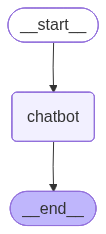

In [6]:
from IPython.display import Image

Image(chat_graph.get_graph().draw_mermaid_png())

In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


def chatbot(state: OrderState) -> OrderState:
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}


graph_builder = StateGraph(OrderState)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
chat_graph = graph_builder.compile()

In [10]:
from pprint import pprint
from langchain_core.messages import HumanMessage

user_msg = "What drinks do you have?"

state = chat_graph.invoke({
    "messages": [HumanMessage(content=user_msg)],
    "order": [],
    "finished": False
})

for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: What drinks do you have?
AIMessage: We have a variety of delicious drinks! Our current selection includes:

**Espresso-based:**
*   **Espresso** (single or double shot)
*   **Americano**
*   **Latte**
*   **Cappuccino**
*   **Mocha**

**Brewed Coffee:**
*   **Drip Coffee** (Light, Medium, Dark Roast)

**Tea:**
*   **Green Tea**
*   **Black Tea**
*   **Herbal Tea**

**Other:**
*   **Hot Chocolate**
*   **Chai Latte**
*   **Iced Coffee**
*   **Iced Tea**

We also have a range of modifiers like different milk options (whole, skim, almond, oat, soy), various syrups (vanilla, caramel, hazelnut), and extra espresso shots.

What sounds good to you today?


In [11]:
user_msg = "Can I order a latte?"

state["messages"].append(HumanMessage(content=user_msg))

state = chat_graph.invoke(state)

for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: What drinks do you have?
AIMessage: We have a variety of delicious drinks! Our current selection includes:

**Espresso-based:**
*   **Espresso** (single or double shot)
*   **Americano**
*   **Latte**
*   **Cappuccino**
*   **Mocha**

**Brewed Coffee:**
*   **Drip Coffee** (Light, Medium, Dark Roast)

**Tea:**
*   **Green Tea**
*   **Black Tea**
*   **Herbal Tea**

**Other:**
*   **Hot Chocolate**
*   **Chai Latte**
*   **Iced Coffee**
*   **Iced Tea**

We also have a range of modifiers like different milk options (whole, skim, almond, oat, soy), various syrups (vanilla, caramel, hazelnut), and extra espresso shots.

What sounds good to you today?
HumanMessage: Can I order a latte?
AIMessage: Absolutely! A latte sounds like a great choice.

Would you like any modifications with your latte, such as a specific milk (whole, skim, almond, oat, soy) or a syrup (vanilla, caramel, hazelnut)? Or perhaps an extra espresso shot?


In [12]:
from langchain_core.messages.ai import AIMessage


def human_node(state: OrderState) -> OrderState:
    """Display the last model message to the user, and receive the user's input."""
    last_msg = state["messages"][-1]
    print("Model:", last_msg.content)

    user_input = input("User: ")

    if user_input in {"q", "quit", "exit", "goodbye"}:
        state["finished"] = True

    return state | {"messages": [("user", user_input)]}


def chatbot_with_welcome_msg(state: OrderState) -> OrderState:
    """The chatbot itself. A wrapper around the model's own chat interface."""

    if state["messages"]:
        new_output = llm.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)

    return state | {"messages": [new_output]}


# Start building a new graph.
graph_builder = StateGraph(OrderState)

# Add the chatbot and human nodes to the app graph.
graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)

# Start with the chatbot again.
graph_builder.add_edge(START, "chatbot")

# The chatbot will always go to the human next.
graph_builder.add_edge("chatbot", "human")

In [15]:
graph_builder = StateGraph(OrderState)

graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", "human")

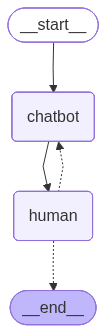

In [16]:
from typing import Literal
from IPython.display import Image


def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
    if state.get("finished", False):
        return END
    else:
        return "chatbot"


graph_builder.add_conditional_edges("human", maybe_exit_human_node)

chat_with_human_graph = graph_builder.compile()

Image(chat_with_human_graph.get_graph().draw_mermaid_png())

In [17]:
from langchain_core.tools import tool


@tool
def get_menu() -> str:
    """Provide the latest up-to-date menu."""
    return """
    MENU:
    Coffee Drinks:
    Espresso
    Americano
    Cold Brew

    Coffee Drinks with Milk:
    Latte
    Cappuccino
    Cortado
    Macchiato
    Mocha
    Flat White

    Tea Drinks:
    English Breakfast Tea
    Green Tea
    Earl Grey

    Tea Drinks with Milk:
    Chai Latte
    Matcha Latte
    London Fog

    Other Drinks:
    Steamer
    Hot Chocolate

    Modifiers:
    Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free; Default option: whole
    Espresso shots: Single, Double, Triple, Quadruple; default: Double
    Caffeine: Decaf, Regular; default: Regular
    Hot-Iced: Hot, Iced; Default: Hot
    Sweeteners: vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce, sugar free vanilla sweetener
    Special requests: extra hot, one pump, half caff, extra foam, etc.

    Soy milk has run out of stock today, so soy is not available.
    """

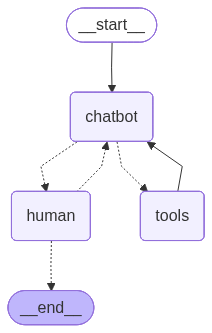

In [18]:
from langgraph.prebuilt import ToolNode
from typing import Literal
from IPython.display import Image


tools = [get_menu]
tool_node = ToolNode(tools)

llm_with_tools = llm.bind_tools(tools)


def maybe_route_to_tools(state: OrderState) -> Literal["tools", "human"]:
    """Route between human or tool nodes, depending if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    msg = msgs[-1]

    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        return "tools"
    else:
        return "human"


def chatbot_with_tools(state: OrderState) -> OrderState:
    """The chatbot with tools. A simple wrapper around the model's own chat interface."""
    defaults = {"order": [], "finished": False}

    if state["messages"]:
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)

    return defaults | state | {"messages": [new_output]}


graph_builder = StateGraph(OrderState)

graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

graph_builder.add_edge("tools", "chatbot")

graph_builder.add_edge(START, "chatbot")

graph_with_menu = graph_builder.compile()

Image(graph_with_menu.get_graph().draw_mermaid_png())

In [19]:
from collections.abc import Iterable
from random import randint

from langgraph.prebuilt import InjectedState
from langchain_core.messages.tool import ToolMessage


@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Adds the specified drink to the customer's order, including any modifiers.

    Returns:
      The updated order in progress.
    """


@tool
def confirm_order() -> str:
    """Asks the customer if the order is correct.

    Returns:
      The user's free-text response.
    """


@tool
def get_order() -> str:
    """Returns the users order so far. One item per line."""


@tool
def clear_order():
    """Removes all items from the user's order."""


@tool
def place_order() -> int:
    """Sends the order to the barista for fulfillment.

    Returns:
      The estimated number of minutes until the order is ready.
    """


def order_node(state: OrderState) -> OrderState:
    """The ordering node. This is where the order state is manipulated."""
    tool_msg = state["messages"][-1]
    order = state.get("order", [])
    outbound_msgs = []
    order_placed = False

    for tool_call in tool_msg.tool_calls:

        if tool_call["name"] == "add_to_order":
            modifiers = tool_call["args"].get("modifiers", [])
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"

            order.append(f'{tool_call["args"]["drink"]} ({modifier_str})')
            response = "\n".join(order)

        elif tool_call["name"] == "confirm_order":
            print("Your order:")

            if not order:
                print("  (no items)")

            for drink in order:
                print(f"  {drink}")

            response = input("Is this correct? ")

        elif tool_call["name"] == "get_order":
            response = "\n".join(order) if order else "(no order)"

        elif tool_call["name"] == "clear_order":
            order.clear()
            response = "Order cleared."

        elif tool_call["name"] == "place_order":
            order_text = "\n".join(order)
            print("Sending order to kitchen!")
            print(order_text)

            order_placed = True
            response = randint(1, 5)

        else:
            raise NotImplementedError(f'Unknown tool call: {tool_call["name"]}')

        outbound_msgs.append(
            ToolMessage(
                content=str(response),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )

    return {
        "messages": outbound_msgs,
        "order": order,
        "finished": order_placed
    }


def maybe_route_to_tools(state: OrderState) -> str:
    """Route between chat and tool nodes if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    msg = msgs[-1]

    if state.get("finished", False):
        return END

    elif hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        if any(
            tool["name"] in tool_node.tools_by_name.keys()
            for tool in msg.tool_calls
        ):
            return "tools"
        else:
            return "ordering"

    else:
        return "human"

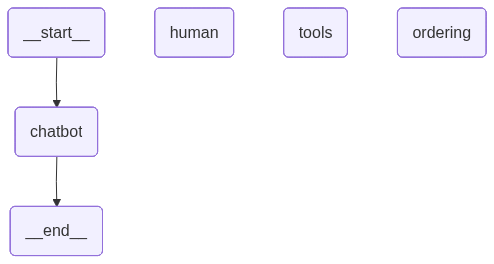

In [20]:
# Auto-tools will be invoked automatically by the ToolNode
auto_tools = [get_menu]
tool_node = ToolNode(auto_tools)

# Order-tools will be handled by the order node.
order_tools = [
    add_to_order,
    confirm_order,
    get_order,
    clear_order,
    place_order
]

# The LLM needs to know about all of the tools, so specify everything here.
llm_with_tools = llm.bind_tools(auto_tools + order_tools)


graph_builder = StateGraph(OrderState)

# Nodes
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("ordering", order_node)

# Chatbot -> {ordering, tools, human, END}
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)

# Human -> {chatbot, END}
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

# Tools both kinds always route back to chat afterwards.
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("ordering", "chatbot")

graph_builder.add_edge(START, "chatbot")

graph_with_order_tools = graph_builder.compile()

Image(graph_with_order_tools.get_graph().draw_mermaid_png())

In [21]:
from pprint import pprint

config = {"recursion_limit": 100}

state = graph_with_order_tools.invoke(
    {"messages": [], "order": [], "finished": False},
    config
)

pprint(state)

Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: I want an iced latte with oat milk
Model: [{'type': 'text', 'text': 'Sounds good! You want an Iced Latte with Oat milk. Would you like anything else or are you ready to confirm your order?', 'extras': {'signature': 'CogBAQw51semaUDHirQDH2Q8cZYbImYETLF65pLp4/Dn6gccrh/FpAFDZDMGxThHc1Qrcla2X2wwc88MXNLewd/yGQ7RNcFK1ZLVRDUu3/eAPjfIVzNKwTmXguBg6mNHHRRfIZQ/HOF556YkX8U865ZoRlS+SgFA7xZ3XMsdIAPjz/lK/sckkD9NnA=='}}]
User: ready to confirm
Your order:
  Latte (Iced, Oat)
Is this correct? Yes
Sending order to kitchen!
Latte (Iced, Oat)
{'finished': True,
 'messages': [AIMessage(content='Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?', additional_kwargs={}, response_metadata={}, id='2a19c058-3d36-4e5b-b3b0-84ba682d7de2', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='I want an iced latte with oat milk', additional_kwargs={}, response_metadata={}, id='c59